In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
df=pd.read_csv("C:/Users/Diya/Downloads/cleaned_salaries.csv")

In [5]:
df = df.drop(['salary','salary_currency'], axis=1)

In [6]:
df=pd.get_dummies(df, columns=[
    'experience_level',
    'employment_type',
    'job_title',
    'employee_residence',
    'company_location',
    'company_size'
])

In [7]:
df.head()
df.dtypes

work_year                       int64
salary_in_usd                   int64
remote_ratio                    int64
experience_level_Entry-Level     bool
experience_level_Executive       bool
                                ...  
company_location_US              bool
company_location_VN              bool
company_size_Large               bool
company_size_Medium              bool
company_size_Small               bool
Length: 170, dtype: object

In [8]:
x = df.drop('salary_in_usd', axis=1)
y = df['salary_in_usd']

In [9]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [10]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [11]:
from sklearn.ensemble import RandomForestRegressor
rf=RandomForestRegressor()
rf.fit(x_train,y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [12]:
y_pred_lr=lr.predict(x_test)
y_pred_rf=rf.predict(x_test)

In [13]:
from sklearn.metrics import r2_score, mean_absolute_error
print("Linear Regression R2:", r2_score(y_test, y_pred_lr))
print("Random Forest R2:", r2_score(y_test, y_pred_rf))
print("LR MAE:", mean_absolute_error(y_test, y_pred_lr))
print("RF MAE:", mean_absolute_error(y_test, y_pred_rf))

Linear Regression R2: 0.5239503527532076
Random Forest R2: 0.594624411480999
LR MAE: 29943.07664525503
RF MAE: 27027.221512170323


<Axes: >

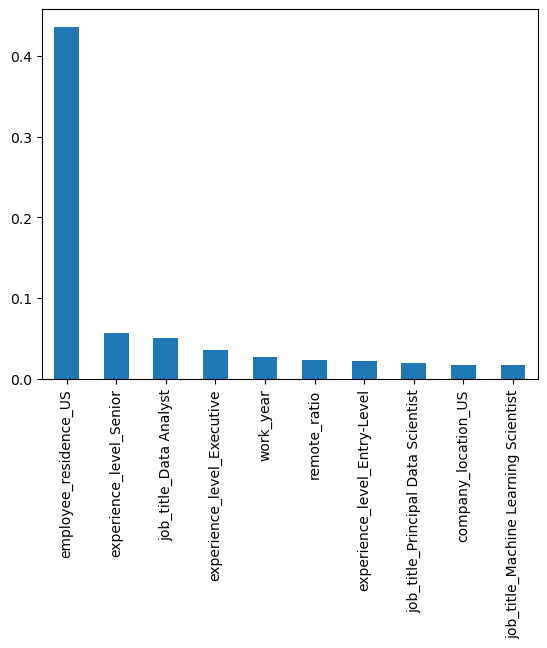

In [14]:
importance=pd.Series(rf.feature_importances_,index=x.columns)
importance.sort_values(ascending=False).head(10).plot(kind='bar')

In [15]:
import joblib
joblib.dump(rf, 'salary_model.joblib')

['salary_model.joblib']

In [16]:
model=joblib.load('salary_model.joblib')

In [18]:
import joblib
joblib.dump(x.columns, 'model_columns.joblib')

['model_columns.joblib']